# Sine Wave Regression: Continual Learning with Hamiltonian Gradients

This notebook demonstrates continual learning on a sine wave regression task using the ContLearn framework.

## Overview
- **Dataset**: Sine waves with frequency and amplitude drift across tasks
- **Model**: Multi-layer Perceptron (MLP/FCNN)
- **Methods**: Baseline vs AWB Full (Adaptive Weight Basis)
- **Metrics**: MSE, Backward Transfer, Forgetting

## Contents
1. [Part 1: Quick Training Demo](#part1) - Run minimal training (requires compute)
2. [Part 2: Load Pre-computed Results](#part2) - Analyze saved experiments
3. [Part 3: Comparison Plot](#part3) - Compare Baseline vs AWB

In [1]:
# Setup
import sys
import os

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, project_root)
sys.path.insert(0, os.path.join(project_root, 'src'))
sys.path.insert(0, os.path.join(project_root, 'examples'))

import numpy as np
import matplotlib.pyplot as plt
from utils import load_results, compute_cl_metrics, plot_comparison, print_experiment_summary

print(f"Project root: {project_root}")

Project root: /Users/kraghavan/Desktop/projs/JMLR_paper/ContLearn


<a id='part1'></a>
## Part 1: Quick Training Demo (Optional)

This section demonstrates how to run a minimal training experiment. **Skip this if you don't have JAX/GPU available.**

In [2]:
# Optional: Run minimal training demo
# Uncomment the lines below to run

# import jax
# from cl.config import load_config
# from cl.runners import train_model
# 
# # Check JAX backend
# print(f"JAX Backend: {jax.default_backend()}")
# print(f"JAX Devices: {jax.devices()}")
# 
# # Load example config (debug mode for quick demo)
# config_path = os.path.join(project_root, 'examples/configs/sine_baseline.json')
# config = load_config(config_path)
# 
# print(f"\nConfig loaded:")
# print(f"  Dataset: {config.get('data')}")
# print(f"  Tasks: {config.get('n_task')}")
# print(f"  Epochs per task: {config.get('epochs_per_task')}")
# print(f"  Debug mode: {config.get('debug_mode')}")
# 
# # Run training (takes ~1-2 minutes with debug mode)
# record_dict = train_model(config, run_id=0)

<a id='part2'></a>
## Part 2: Load Pre-computed Results

Load and explore the structure of saved experiment results.

In [3]:
# Load pre-computed results
data_dir = os.path.join(project_root, 'examples/data/sine')

baseline_data = load_results(os.path.join(data_dir, 'baseline_run0.pkl'))
awb_data = load_results(os.path.join(data_dir, 'awb_full_run0.pkl'))

print("Loaded baseline and AWB results!")

Loaded baseline and AWB results!


In [4]:
# Explore data structure
print("Keys in data dictionary:")
print(list(baseline_data.keys()))

print("\nMetadata:")
for key, value in baseline_data.get('metadata', {}).items():
    print(f"  {key}: {value}")

Keys in data dictionary:
['metadata', 'tasks', 'architecture_history', 'iterations', 'task_performance_matrix']

Metadata:
  problem: vectors
  prob: regression
  dataset: sine
  network: fcnn
  loss_function: mse
  metric_function: mse
  n_tasks: 5
  epochs_per_task: 500
  save_iter: 50
  learning_rate: 0.0001
  batch_size: 1024
  awb_enabled: False
  run_id: 0


In [5]:
# Print experiment summaries
print_experiment_summary(baseline_data, name='Sine Baseline')
print_experiment_summary(awb_data, name='Sine AWB Full')


 Sine Baseline Summary
Tasks: 5
Epochs per task: 500
Problem type: vectors
Network: fcnn
AWB enabled: False

Continual Learning Metrics:
  Average Accuracy: 0.0258
  Backward Transfer: -0.0019
  Forgetting: 0.0019


 Sine AWB Full Summary
Tasks: 5
Epochs per task: 500
Problem type: vectors
Network: fcnn
AWB enabled: True

Continual Learning Metrics:
  Average Accuracy: 0.0117
  Backward Transfer: -0.0058
  Forgetting: 0.0060



### Explore Training Metrics

The `tasks` dictionary contains per-task training data with keys:
- `H`: Hamiltonian (total loss)
- `V`: Experience replay loss
- `grad_norm`: Gradient L2 norm
- `test_current`: Test MSE on current task
- `test_experience`: Test MSE on experience replay

In [6]:
# Look at task 0 training data
task_0 = baseline_data['tasks'][0]['main_training']
print("Available metrics for task 0:")
for key in task_0.keys():
    if isinstance(task_0[key], list):
        print(f"  {key}: {len(task_0[key])} values")
    else:
        print(f"  {key}: {task_0[key]}")

Available metrics for task 0:
  iterations: 10 values
  epochs: 10 values
  H: 10 values
  V: 10 values
  dV: 10 values
  dV_dx: 10 values
  dV_dtheta: 10 values
  grad_norm: 10 values
  train_metric: 10 values
  test_current: 10 values
  test_experience: 10 values
  eigenvalues: {'A': {}, 'B': {}}


<a id='part3'></a>
## Part 3: Comparison Plot

Create a publication-quality 4-panel comparison of Baseline vs AWB methods.

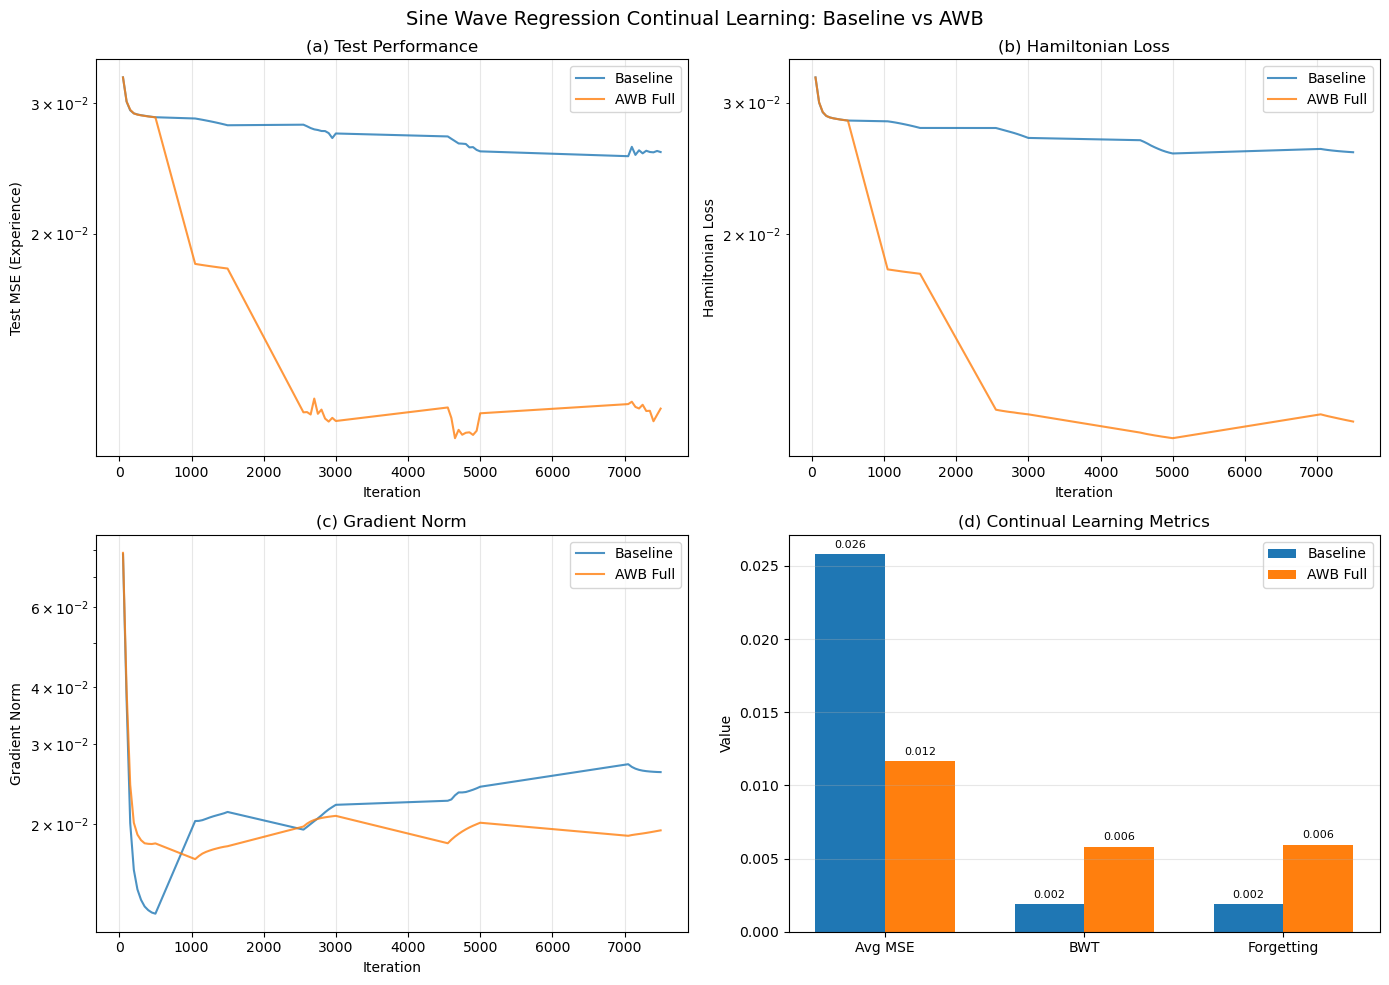

In [7]:
# Create comparison plot
fig = plot_comparison(
    baseline_data, 
    awb_data, 
    metric_type='mse',
    title_prefix='Sine Wave Regression'
)
plt.show()

In [8]:
# Optional: Save figure
# fig.savefig('sine_comparison.pdf', dpi=300, bbox_inches='tight')

## Summary

### Key Observations

1. **Test MSE**: AWB achieves lower MSE, especially on experience replay
2. **Hamiltonian Loss**: AWB shows smoother optimization trajectory
3. **Gradient Norm**: Both methods show similar gradient dynamics
4. **CL Metrics**: 
   - AWB has better average MSE
   - Both show minimal forgetting on this task

### The AWB Advantage

AWB (Adaptive Weight Basis) provides:
- Architecture search to find optimal layer sizes
- A/B matrix transfer for smooth knowledge transfer
- Task warmup for stable transition between tasks